In [9]:
import pandas as pd

file_path = r"C:\Users\tommy\PycharmProjects\Credit-Risk-Student-Workspace\Tommy_workspace\Section2\EFM Asia daily.xlsx"

df = pd.read_excel(file_path, skiprows=6)

df = df.rename(columns={
    df.columns[0]: "Date",
    df.columns[1]: "Price"
})

df = df.dropna(subset=["Date", "Price"])

df["Date"] = pd.to_datetime(df["Date"])

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

df = df.dropna(subset=["Price"])

df = df.sort_values(by="Date")

df["Return"] = df["Price"].pct_change()

returns_df = df[["Date", "Return"]].dropna().set_index("Date")

print(returns_df.head())
print(returns_df.tail())

              Return
Date                
2020-03-10  0.015068
2020-03-11 -0.013913
2020-03-12 -0.052981
2020-03-13 -0.003015
2020-03-16 -0.056605
              Return
Date                
2024-01-22 -0.007846
2024-01-23  0.006501
2024-01-30  0.011769
2024-01-31 -0.006524
2024-02-01  0.005890



 Task 2: Plot the Return Distribution
 --------------------------------------------------
 - Plot a histogram of daily returns.
 - Choose a reasonable number of bins (e.g., 30–50).

- Add vertical lines for:
     1. Mean return
     2. 5% quantile (this corresponds to 95% VaR)

 - Label axes clearly:
     x-axis: Return
     y-axis: Frequency

 - Add a title and legend.

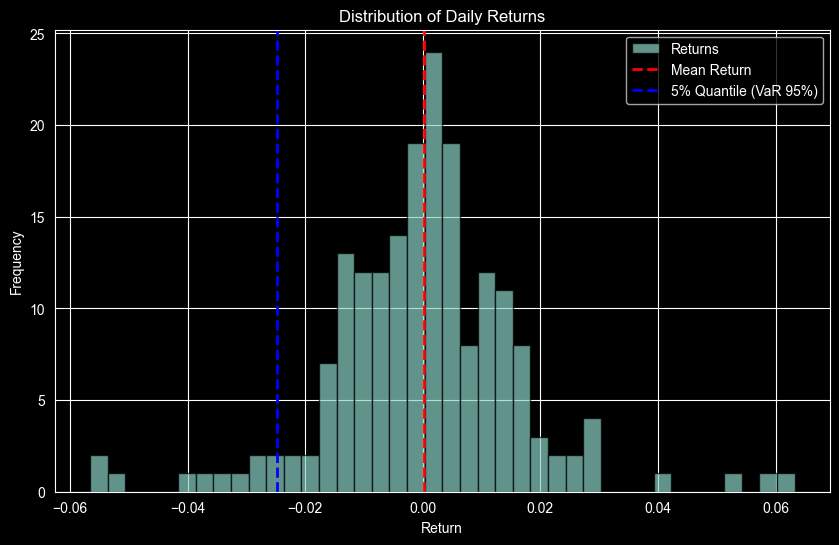

In [10]:
import matplotlib.pyplot as plt

returns = returns_df["Return"].dropna()

mean_return = returns.mean()
var_95 = returns.quantile(0.05)

plt.figure(figsize=(10, 6))

plt.hist(returns, bins=40, edgecolor="black", alpha=0.7, label="Returns")

plt.axvline(mean_return, color="red", linestyle="--", linewidth=2, label="Mean Return")
plt.axvline(var_95, color="blue", linestyle="--", linewidth=2, label="5% Quantile (VaR 95%)")

plt.title("Distribution of Daily Returns")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.legend()

plt.show()

Task 3: Compute Risk Measures
 --------------------------------------------------
 - Compute:

     mean_return = returns_df["Return"].mean()
     quantile_5 = returns_df["Return"].quantile(0.05)
     VaR_95 = -quantile_5

 - Print all three values.

 Interpretation:
 VaR should be reported as a positive number representing loss.

In [11]:
mean_return = returns.mean()
quantile_5 = returns.quantile(0.05)
VaR_95 = -quantile_5

print("Mean Return:", mean_return)
print("5% Quantile:", quantile_5)
print("VaR (95%):", VaR_95)

Mean Return: 0.00022780826250694812
5% Quantile: -0.024808728524132517
VaR (95%): 0.024808728524132517


 --------------------------------------------------
 Task 4: Interpretation Questions
 --------------------------------------------------
 Answer the following:

 1. Distribution shape
    - Is the return distribution symmetric?
No, it is a bit skewed to the left

    - Do you observe fat tails or extreme values?
Yes, there are some extreme negative returns (losses) in the left tail.

 2. Mean vs risk
    - Compare the mean return to the VaR.
The mean return is positive, indicating that on average, the returns are profitable. However, the VaR at 95% is a negative value, which indicates that there is a 5% chance of experiencing a loss greater than this amount. This shows that while the average return is positive, there is still a significant risk of extreme negative outcomes.

    - What does this tell you about average vs extreme outcomes?
This indicates that while the average outcome is positive, there is a non-negligible risk of experiencing significant losses. It highlights the importance of considering not just the average return but also the potential for extreme negative outcomes when assessing the risk of an investment.

 3. VaR interpretation
    - Explain in words:
      “What does a 95% VaR of X% mean?”
A 95% VaR of X% means that there is a 5% chance that the return on the investment will be worse than X%.

 4. Tail behavior
    - Look at the left tail (loss side).
    - Are extreme losses frequent or rare?
 rare, but they do occur.